In [ ]:
!pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.1/312.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import matplotlib.pyplot as plt
from sklearn.base import clone
from collections import Counter

In [ ]:
df = pd.read_csv('SKCM_transposed.csv')
df

,index,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,...,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS,TumorType
0,TCGA-YD-A89C-06,9.1174,4.8009,0.0000,12.2729,9.5878,8.8964,13.4528,2.8214,0.0000,...,0.0000,0.9006,2.1595,9.3527,9.5674,5.5530,10.7613,0.5195,12.3526,Metastatic
1,TCGA-Z2-AA3V-06,10.4428,3.2481,0.0000,11.8799,7.9206,7.8771,11.0965,6.7228,0.0000,...,0.0000,6.4482,0.0000,10.5334,13.1342,8.0112,12.1952,3.4341,9.2630,Metastatic
2,TCGA-EB-A3Y6-01,9.5005,2.8755,0.0000,11.1628,10.5951,10.7658,12.2313,4.5467,0.0000,...,0.0000,3.7737,1.8520,9.1434,11.3672,6.8652,11.7054,1.8520,10.7168,Primary
3,TCGA-EE-A3JA-06,6.8912,1.9354,0.0000,11.8069,11.7913,11.3248,12.2683,2.2529,0.0000,...,0.0000,5.1251,3.3808,10.0605,11.3976,5.2374,10.7286,5.3416,9.6598,Metastatic
4,TCGA-D9-A4Z2-01,9.7355,6.2338,6.9095,12.1793,10.8435,10.4549,12.5040,6.4743,0.4147,...,0.0000,2.2213,4.0575,9.5435,11.7295,6.6034,11.3317,5.2210,10.2599,Primary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,TCGA-FW-A3R5-06,8.8754,1.5959,0.0000,11.4630,11.1037,11.1112,11.8086,4.3376,0.0000,...,0.0000,3.4300,0.0000,10.2964,11.0185,7.5294,10.7449,7.7099,11.0719,Metastatic
469,TCGA-D3-A3MR-06,9.9149,3.4829,0.0000,12.1227,10.1511,10.4634,12.3372,4.6998,0.9452,...,3.0711,6.5333,2.9894,10.3962,13.2023,7.6168,12.9046,6.3653,10.5177,Metastatic
470,TCGA-D3-A51E-06,9.1211,2.0025,1.1945,11.4185,11.4476,10.5932,11.4392,1.6543,0.0000,...,0.0000,4.8105,2.7190,10.2026,12.3005,5.8612,11.6455,1.6543,10.7396,Metastatic
471,TCGA-GN-A4U7-06,8.7848,2.1842,0.0000,12.2270,10.6454,9.4267,12.2119,2.4745,0.0000,...,0.0000,2.4745,0.5911,11.0348,11.4077,5.7729,12.2293,2.6003,10.6390,Metastatic


In [ ]:
X = df.drop(columns=['sample', 'index', 'TumorType'], errors='ignore')
y = (df['TumorType'] == 'Metastatic').astype(int)

# --- ANOVA feature selection ---
selector = SelectKBest(score_func=f_classif, k=500)
X_selected = selector.fit_transform(X, y)
selected_feature_names = X.columns[selector.get_support(indices=True)]

# For downstream compatibility, convert to DataFrame
X_selected_df = pd.DataFrame(X_selected, columns=selected_feature_names)

# --- Classifiers ---
classifiers = {
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "Gradient Boost": GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(C=1, penalty='l1', solver='liblinear', max_iter=500),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=5, max_depth=None, random_state=42),
    "SVC": SVC(C=0.1, class_weight=None, gamma='scale', kernel='linear', probability=True),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', alpha=1e-4, learning_rate_init=1e-3, max_iter=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=11, use_label_encoder=False, eval_metric='logloss'),
}

# --- Cross-Validation Setup ---
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
results = []

for clf_name, clf in classifiers.items():
    fold_metrics = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_selected_df, y)):
        X_train, X_test = X_selected_df.iloc[train_idx], X_selected_df.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
        )

        # Fit on train_fold (val_fold is currently unused, consistent with your first script)
        clf.fit(X_train_fold, y_train_fold)
        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
        rec = recall_score(y_test, y_pred, average="binary", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)

        fold_metrics.append({
            "Classifier": clf_name,
            "Fold": fold + 1,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-score": f1,
        })

    # Compute average and std for each metric
    accs = [m["Accuracy"] for m in fold_metrics]
    precs = [m["Precision"] for m in fold_metrics]
    recs = [m["Recall"] for m in fold_metrics]
    f1s = [m["F1-score"] for m in fold_metrics]

    avg_results = {
        "Classifier": clf_name,
        "Fold": "Average",
        "Accuracy": np.mean(accs),
        "Accuracy_std": np.std(accs),
        "Precision": np.mean(precs),
        "Precision_std": np.std(precs),
        "Recall": np.mean(recs),
        "Recall_std": np.std(recs),
        "F1-score": np.mean(f1s),
        "F1-score_std": np.std(f1s),
    }
    results.append(avg_results)

    print(
        f"{clf_name}: "
        f"Accuracy = {avg_results['Accuracy']:.3f}±{avg_results['Accuracy_std']:.3f}, "
        f"Precision = {avg_results['Precision']:.3f}±{avg_results['Precision_std']:.3f}, "
        f"Recall = {avg_results['Recall']:.3f}±{avg_results['Recall_std']:.3f}, "
        f"F1 Score = {avg_results['F1-score']:.3f}±{avg_results['F1-score_std']:.3f}"
    )

anova_500_df = pd.concat(
    [
        df[["index"]].reset_index(drop=True),
        X_selected_df.reset_index(drop=True),
        y.reset_index(drop=True).rename("TumorType")
    ],
    axis=1
)

anova_500_df.to_csv("SKCM_ANOVA_top500.csv", index=False)
results_df = pd.DataFrame(results)
results_df.to_csv("all_classifiers_cv_results.csv", index=False)
print("\nAll results saved to all_classifiers_cv_results.csv")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  144   283   284   297   321   365   565   732   819   839   878  1077
  1100  1188  1255  1256  1257  1259  1338  1399  1425  1430  1459  1461
  1619  1655  1743  1765  1766  1891  1993  1994  2003  2031  2032  2224
  2225  2231  2236  2409  2476  2690  2691  2693  2698  2699  2733  2889
  2903  2942  2944  3039  3048  3049  3054  3076  3079  3206  3273  3284
  3288  3425  3551  3895  3994  4026  4036  4050  4051  4052  4135  4205
  4922  4933  5009  5033  5066  5242  5299  5371  5418  5439  5607  5608
  5609  5610  5648  5755  6030  6049  6051  6118  6125  6147  6323  6324
  6825  6852  6855  6856  6860  7207  7218  7357  7403  7420  7421  7440
  7602  7650  7857  7858  7967  7995  8000  8025  8107  8276  9029  9200
  9305  9485  9493  9495  9621  9625  9666  9755  9759  9969 10262 10315
 10458 10464 10502 10565 10608 10668 10690 10958 10959 10962 10963 10964
 10965

AdaBoost: Accuracy = 0.920±0.005, Precision = 0.928±0.012, Recall = 0.973±0.015, F1 Score = 0.950±0.003
Decision Tree: Accuracy = 0.835±0.043, Precision = 0.910±0.021, Recall = 0.875±0.039, F1 Score = 0.892±0.029
Extra Trees: Accuracy = 0.899±0.016, Precision = 0.900±0.012, Recall = 0.978±0.014, F1 Score = 0.938±0.009
Gradient Boost: Accuracy = 0.886±0.027, Precision = 0.923±0.012, Recall = 0.932±0.042, F1 Score = 0.927±0.019
KNN: Accuracy = 0.899±0.023, Precision = 0.915±0.014, Recall = 0.959±0.024, F1 Score = 0.936±0.015
Logistic Regression: Accuracy = 0.920±0.023, Precision = 0.947±0.017, Recall = 0.951±0.033, F1 Score = 0.948±0.015
Naive Bayes: Accuracy = 0.856±0.023, Precision = 0.881±0.005, Recall = 0.943±0.031, F1 Score = 0.911±0.016
Random Forest: Accuracy = 0.890±0.018, Precision = 0.894±0.017, Recall = 0.976±0.016, F1 Score = 0.933±0.011
SVC: Accuracy = 0.913±0.008, Precision = 0.932±0.009, Recall = 0.959±0.012, F1 Score = 0.945±0.005
MLP: Accuracy = 0.932±0.015, Precision = 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:04:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:04:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:04:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:04:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:04:13] WARNING: /w

XGBoost: Accuracy = 0.932±0.016, Precision = 0.938±0.023, Recall = 0.978±0.007, F1 Score = 0.958±0.009

All results saved to all_classifiers_cv_results.csv


In [ ]:
# --- Mutual Information feature selection ---
selector = SelectKBest(score_func=mutual_info_classif, k=500)
X_selected = selector.fit_transform(X, y)
selected_feature_names = X.columns[selector.get_support(indices=True)]

# For downstream compatibility, convert to DataFrame
X_selected_df = pd.DataFrame(X_selected, columns=selected_feature_names)

classifiers = {
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "Gradient Boost": GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(C=1, penalty='l1', solver='liblinear', max_iter=500),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=5, max_depth=None, random_state=42),
    "SVC": SVC(C=0.1, class_weight=None, gamma='scale', kernel='linear', probability=True),
    "MLP": MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation='relu',
                solver='adam',
                alpha=1e-4,
                batch_size='auto',
                learning_rate_init=1e-3,
                max_iter=300,
                random_state=42
            ),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=11, use_label_encoder=False, eval_metric='logloss'),
}

# --- Cross-Validation Setup ---
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
results = []

for clf_name, clf in classifiers.items():
    fold_metrics = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_selected_df, y)):
        X_train, X_test = X_selected_df.iloc[train_idx], X_selected_df.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
        )

        clf.fit(X_train_fold, y_train_fold)
        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
        rec = recall_score(y_test, y_pred, average="binary", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)

        fold_metrics.append({
            "Classifier": clf_name,
            "Fold": fold + 1,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-score": f1,
        })

    # Compute average and std for each metric
    accs = [m["Accuracy"] for m in fold_metrics]
    precs = [m["Precision"] for m in fold_metrics]
    recs = [m["Recall"] for m in fold_metrics]
    f1s = [m["F1-score"] for m in fold_metrics]

    avg_results = {
        "Classifier": clf_name,
        "Fold": "Average",
        "Accuracy": np.mean(accs),
        "Accuracy_std": np.std(accs),
        "Precision": np.mean(precs),
        "Precision_std": np.std(precs),
        "Recall": np.mean(recs),
        "Recall_std": np.std(recs),
        "F1-score": np.mean(f1s),
        "F1-score_std": np.std(f1s),
    }
    results.append(avg_results)

    print(
        f"{clf_name}: "
        f"Accuracy = {avg_results['Accuracy']:.3f}±{avg_results['Accuracy_std']:.3f}, "
        f"Precision = {avg_results['Precision']:.3f}±{avg_results['Precision_std']:.3f}, "
        f"Recall = {avg_results['Recall']:.3f}±{avg_results['Recall_std']:.3f}, "
        f"F1 Score = {avg_results['F1-score']:.3f}±{avg_results['F1-score_std']:.3f}"
    )

results_df = pd.DataFrame(results)
print("\nAll results saved to all_classifiers_cv_results_mi.csv")

mi_500_df = pd.concat(
    [
        df[['index']].reset_index(drop=True),
        X_selected_df.reset_index(drop=True),
        y.reset_index(drop=True).rename("TumorType")
    ],
    axis=1
)
mi_500_df.to_csv("SKCM_MI_top500_with_target.csv", index=False)
results_df.to_csv("all_classifiers_cv_results_mi.csv", index=False)
print("Saved: SKCM_MI_top500_with_target.csv")

AdaBoost: Accuracy = 0.932±0.008, Precision = 0.938±0.008, Recall = 0.978±0.018, F1 Score = 0.958±0.006
Decision Tree: Accuracy = 0.856±0.037, Precision = 0.909±0.039, Recall = 0.908±0.020, F1 Score = 0.908±0.022
Extra Trees: Accuracy = 0.890±0.014, Precision = 0.893±0.008, Recall = 0.976±0.016, F1 Score = 0.933±0.009
Gradient Boost: Accuracy = 0.871±0.030, Precision = 0.919±0.019, Recall = 0.916±0.025, F1 Score = 0.917±0.019
KNN: Accuracy = 0.888±0.017, Precision = 0.905±0.012, Recall = 0.957±0.020, F1 Score = 0.930±0.011
Logistic Regression: Accuracy = 0.915±0.026, Precision = 0.943±0.016, Recall = 0.949±0.022, F1 Score = 0.946±0.017
Naive Bayes: Accuracy = 0.858±0.026, Precision = 0.881±0.006, Recall = 0.946±0.034, F1 Score = 0.912±0.017
Random Forest: Accuracy = 0.890±0.005, Precision = 0.896±0.014, Recall = 0.973±0.017, F1 Score = 0.932±0.003
SVC: Accuracy = 0.909±0.020, Precision = 0.936±0.018, Recall = 0.949±0.018, F1 Score = 0.942±0.012
MLP: Accuracy = 0.920±0.020, Precision = 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:44:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:44:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:44:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:44:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:44:45] WARNING: /w

XGBoost: Accuracy = 0.918±0.012, Precision = 0.928±0.012, Recall = 0.970±0.016, F1 Score = 0.948±0.008

All results saved to all_classifiers_cv_results_mi.csv
Saved: SKCM_MI_top500_with_target.csv



==== Running NSGA-II feature selection with CV for Logistic Regression ====
Model: Logistic Regression, Fold 1/5
Model: Logistic Regression, Fold 2/5
Model: Logistic Regression, Fold 3/5
Model: Logistic Regression, Fold 4/5
Model: Logistic Regression, Fold 5/5

==== Running NSGA-II feature selection with CV for SVC ====
Model: SVC, Fold 1/5
Model: SVC, Fold 2/5
Model: SVC, Fold 3/5
Model: SVC, Fold 4/5
Model: SVC, Fold 5/5

==== Running NSGA-II feature selection with CV for XGBoost ====
Model: XGBoost, Fold 1/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:54:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:54:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:54:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:54:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:54:33] WARNING: /w

Model: XGBoost, Fold 2/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:01:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:01:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:01:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:01:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:01:33] WARNING: /w

Model: XGBoost, Fold 3/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:09:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:09:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:09:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:09:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:09:41] WARNING: /w

Model: XGBoost, Fold 4/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:17:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:17:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:17:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:17:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:17:25] WARNING: /w

Model: XGBoost, Fold 5/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:24:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:24:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:24:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:24:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:24:46] WARNING: /w

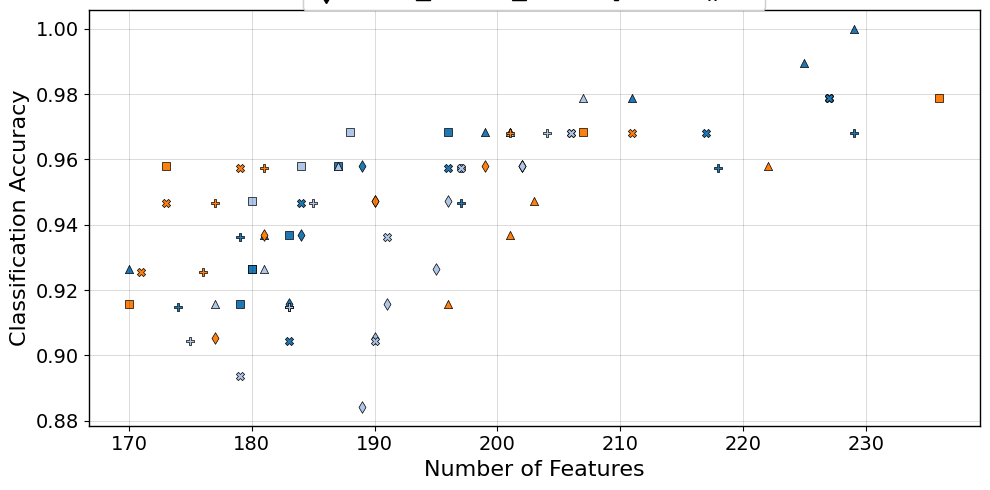

Saved all Pareto front results to CV_ParetoFront_SelectedModels.csv


In [ ]:
df1 = pd.read_csv('SKCM_ANOVA_top500.csv')
X = df1.drop(columns=['sample', 'index', 'TumorType'], errors='ignore')
y = df1['TumorType']

feature_names = X.columns.tolist()

ALL_MODELS = {
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "Gradient Boost": GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(C=1, penalty='l1', solver='liblinear', max_iter=500),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=5, max_depth=None, random_state=42),
    "SVC": SVC(C=0.1, class_weight=None, gamma='scale', kernel='linear', probability=True),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=11, use_label_encoder=False, eval_metric='logloss'),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', alpha=1e-4, learning_rate_init=1e-3, max_iter=200, random_state=42),
}

ABBR = {
    "AdaBoost": "AB",
    "Decision Tree": "DT",
    "Extra Trees": "ET",
    "Gradient Boost": "GB",
    "KNN": "KNN",
    "Logistic Regression": "LR",
    "Naive Bayes": "NB",
    "Random Forest": "RF",
    "SVC": "SVC",
    "XGBoost": "XGB",
    "MLP": "MLP",
}

# 2. Choose which models to run
SELECTED_MODEL_NAMES = ["Logistic Regression", "SVC", "XGBoost"]

# Build selected model dict (and validate names)
missing = [m for m in SELECTED_MODEL_NAMES if m not in ALL_MODELS]
if missing:
    raise ValueError(f"Unknown model names in SELECTED_MODEL_NAMES: {missing}\n"
                     f"Available: {list(ALL_MODELS.keys())}")

models = {name: ALL_MODELS[name] for name in SELECTED_MODEL_NAMES}
abbr = {name: ABBR[name] for name in SELECTED_MODEL_NAMES}

cmap = plt.get_cmap("tab20")
colors = [cmap(i % 20) for i in range(len(models))]

markers = ['d', 's', '^', 'P', 'X']  # for folds

# 3. NSGA-II feature selection with chosen models
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

pareto_full_results = []

fig, ax = plt.subplots(figsize=(10, 5))

for model_idx, (model_name, model_template) in enumerate(models.items()):
    print(f"\n==== Running NSGA-II feature selection with CV for {model_name} ====")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        print(f"Model: {model_name}, Fold {fold}/{n_splits}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        class FeatureSelectionProblem(ElementwiseProblem):
            def __init__(self):
                super().__init__(n_var=len(feature_names), n_obj=2, n_constr=0, xl=0, xu=1)

            def _evaluate(self, x, out, *args, **kwargs):
                indices = np.where(x >= 0.5)[0]
                if len(indices) == 0:
                    out["F"] = [1, 0]  # worst: 1 feature and 0 accuracy
                    return

                sel_feats = [feature_names[i] for i in indices]
                X_train_sel = X_train[sel_feats]
                X_test_sel = X_test[sel_feats]

                try:
                    clf = clone(model_template)  # safe fresh copy each evaluation
                    clf.fit(X_train_sel, y_train)
                    preds = clf.predict(X_test_sel)
                    acc = accuracy_score(y_test, preds)
                except Exception:
                    acc = 0.0

                # minimize (#features), minimize (-accuracy) == maximize accuracy
                out["F"] = [len(indices), -acc]

        problem = FeatureSelectionProblem()
        algorithm = NSGA2(pop_size=50, n_offsprings=10, eliminate_duplicates=True)
        res = minimize(problem, algorithm, ('n_gen', 50), verbose=False)

        pareto = res.F
        num_features = pareto[:, 0]
        accuracy = -pareto[:, 1]

        ax.scatter(
            num_features, accuracy,
            label=f"{abbr[model_name]}-F{fold}",
            color=colors[model_idx],
            marker=markers[(fold - 1) % len(markers)],
            s=35,
            alpha=1,
            edgecolor='black',
            linewidths=0.5
        )

        # Save results
        for i, (num_feats, acc_neg) in enumerate(pareto):
            x_ind = res.X[i]
            selected_indices = np.where(x_ind >= 0.5)[0]
            selected_names = [feature_names[j] for j in selected_indices]

            pareto_full_results.append({
                "Classifier": abbr[model_name],
                "Fold": f"F{fold}",
                "Accuracy": -acc_neg,
                "Number of Features": int(num_feats),
                "Feature Names": "|".join(selected_names)
            })

# 4. Plot styling and legends
ax.set_facecolor('white')
fig.patch.set_alpha(0.0)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

ax.grid(True, color='black', linewidth=0.5, alpha=0.2)
ax.set_xlabel("Number of Features", fontsize=16)
ax.set_ylabel("Classification Accuracy", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

# Legend for classifiers (colors)
handles_classifier = []
for i, name in enumerate(models.keys()):
    h = plt.Line2D(
        [0], [0],
        color=colors[i],
        marker='o',
        linestyle='',
        markersize=10,
        label=abbr[name]
    )
    handles_classifier.append(h)
ax.legend(handles=handles_classifier, fontsize=12, frameon=True,
          loc='lower right', title='Models')

# Legend for folds (markers)
handles_folds = []
fold_labels = [f"f{i}" for i in range(1, n_splits + 1)]
for fold in range(1, n_splits + 1):
    h = plt.Line2D(
        [0], [0],
        color='black',
        marker=markers[(fold - 1) % len(markers)],
        linestyle='',
        markersize=10,
        label=fold_labels[fold - 1]
    )
    handles_folds.append(h)
fold_legend = ax.legend(handles=handles_folds, fontsize=12, frameon=True,
                        loc='upper center', bbox_to_anchor=(0.5, 1.15),
                        ncol=n_splits, title='Folds')
ax.add_artist(fold_legend)

plt.tight_layout()
plt.savefig("CV_ParetoFront_SelectedModels.pdf", dpi=500, transparent=True)
plt.show()

pareto_full_results_df = pd.DataFrame(pareto_full_results)
pareto_full_results_df.to_csv("CV_ParetoFront_SelectedModels.csv", index=False)
print("Saved all Pareto front results to CV_ParetoFront_SelectedModels.csv")

In [ ]:
NSGA_RESULTS_CSV = "CV_ParetoFront_SelectedModels.csv"
DATA_CSV = "SKCM_ANOVA_top500.csv"

# Choose which feature-sets to consider (sources from NSGA file)
SOURCE_CLASSIFIERS_ABBR = ["LR", "SVC", "XGB"]

# Choose which models to evaluate on those feature-sets
MODELS_TO_RUN = {
    "LR": LogisticRegression(C=1, penalty="l1", solver="liblinear", max_iter=500),
    "SVC": SVC(C=0.1, gamma="scale", kernel="linear", probability=True),
    "XGB": XGBClassifier(n_estimators=100, random_state=11, eval_metric="logloss"),
}

# thresholds: features appearing in >=k folds (dynamic)
COMMON_FOLD_THRESHOLDS = [2, 3, 4, 5]

# folds present in your NSGA file
FOLDS = ["F1", "F2", "F3", "F4", "F5"]

# output filenames
RESULTS_OUT_CSV = "Comparative_CommonFeatures_2to5Folds_Selected.csv"

df = pd.read_csv(NSGA_RESULTS_CSV)
data = pd.read_csv(DATA_CSV)
y = data['TumorType']

def clean_feature_list_str(feature_list_str):
    feats = [f.strip() for f in str(feature_list_str).split("|")]
    feats = [
        f for f in feats
        if f and f != "?" and not all(c == "?" for c in f) and f != "26823"
    ]
    return feats


def get_common_features_from_df(df_nsga, source_abbr, folds, min_folds):
    """
    Features counted as present in a fold if they appear in ANY solution row of that fold.
    Then keep features appearing in >= min_folds folds.
    """
    counter = Counter()
    for fold in folds:
        rows = df_nsga[(df_nsga["Classifier"] == source_abbr) & (df_nsga["Fold"] == fold)]
        fold_feats = set()
        for s in rows["Feature Names"].dropna():
            fold_feats.update(clean_feature_list_str(s))
        counter.update(fold_feats)
    return sorted([f for f, c in counter.items() if c >= min_folds])


def evaluate_model_cv(X_sub, y, model, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    accs, precs, recs, f1s = [], [], [], []

    for train_idx, test_idx in skf.split(X_sub, y):
        X_train, X_test = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        clf = clone(model)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred, average="binary", zero_division=0))
        recs.append(recall_score(y_test, y_pred, average="binary", zero_division=0))
        f1s.append(f1_score(y_test, y_pred, average="binary", zero_division=0))

    return {
        "Accuracy_mean": float(np.mean(accs)),
        "Accuracy_std": float(np.std(accs)),
        "Precision_mean": float(np.mean(precs)),
        "Precision_std": float(np.std(precs)),
        "Recall_mean": float(np.mean(recs)),
        "Recall_std": float(np.std(recs)),
        "F1_mean": float(np.mean(f1s)),
        "F1_std": float(np.std(f1s)),
    }



results = []
feature_sets = {}

for source_abbr in SOURCE_CLASSIFIERS_ABBR:
    for min_folds in COMMON_FOLD_THRESHOLDS:
        feats = get_common_features_from_df(df, source_abbr, FOLDS, min_folds=min_folds)

        # only keep features that exist in the actual data matrix
        feats = [f for f in feats if f in data.columns]

        feature_sets[(source_abbr, min_folds)] = feats

        if len(feats) == 0:
            # record empty set and skip evaluation
            for model_key in MODELS_TO_RUN.keys():
                results.append({
                    "SourceFeatureSet": source_abbr,
                    "MinFoldsCommon": min_folds,
                    "NumFeatures": 0,
                    "EvaluatedModel": model_key,
                    "Accuracy_mean": np.nan,
                    "Accuracy_std": np.nan,
                    "Precision_mean": np.nan,
                    "Precision_std": np.nan,
                    "Recall_mean": np.nan,
                    "Recall_std": np.nan,
                    "F1_mean": np.nan,
                    "F1_std": np.nan,
                })
            continue

        X_sub = data[feats].copy()

        for model_key, model in MODELS_TO_RUN.items():
            try:
                metrics = evaluate_model_cv(X_sub, y, model, n_splits=5, seed=42)
            except Exception as e:
                print(f"[WARN] Failed: source={source_abbr}, min_folds={min_folds}, model={model_key} -> {e}")
                metrics = {
                    "Accuracy_mean": np.nan, "Accuracy_std": np.nan,
                    "Precision_mean": np.nan, "Precision_std": np.nan,
                    "Recall_mean": np.nan, "Recall_std": np.nan,
                    "F1_mean": np.nan, "F1_std": np.nan,
                }

            results.append({
                "SourceFeatureSet": source_abbr,
                "MinFoldsCommon": min_folds,
                "NumFeatures": len(feats),
                "EvaluatedModel": model_key,
                **metrics
            })

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_OUT_CSV, index=False)
print(f"Saved all comparisons: {RESULTS_OUT_CSV}")


# 4) Pick the BEST combination by highest Accuracy_mean
valid = results_df.dropna(subset=["Accuracy_mean"]).copy()
if valid.empty:
    raise RuntimeError("No valid results (all NaN). Check your feature names and data columns.")

best = valid.sort_values(
    by=["Accuracy_mean", "Accuracy_std", "NumFeatures"],
    ascending=[False, True, True]
).iloc[0]

best_source = best["SourceFeatureSet"]
best_min_folds = int(best["MinFoldsCommon"])
best_model_key = best["EvaluatedModel"]
best_num_feats = int(best["NumFeatures"])

print("\n===== BEST RESULT =====")
print(best.to_string())


# 5) Save the DATA for the best feature set (genes) + target y
best_features = feature_sets[(best_source, best_min_folds)]
best_features = [f for f in best_features if f in data.columns]

X_best = data[best_features].copy()

# include a clean binary y column
out_df = X_best.copy()
out_df["y"] = y.values

out_df.to_csv("BEST_Common_Subset.csv", index=False)

Saved all comparisons: Comparative_CommonFeatures_2to5Folds_Selected.csv

===== BEST RESULT =====
SourceFeatureSet          LR
MinFoldsCommon             4
NumFeatures              217
EvaluatedModel           XGB
Accuracy_mean       0.936573
Accuracy_std        0.009471
Precision_mean      0.936121
Precision_std       0.016678
Recall_mean         0.986449
Recall_std          0.008547
F1_mean             0.960468
F1_std              0.005571
